In [1]:

import pandas as pd
import re

In [2]:
from sqlalchemy import create_engine

In [13]:
DB_USER ="postgres"
DB_PASS ="rahasia"
DB_HOST ="localhost"
DB_PORT ="5432"
DB_NAME ="project_roti"

In [14]:
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}")

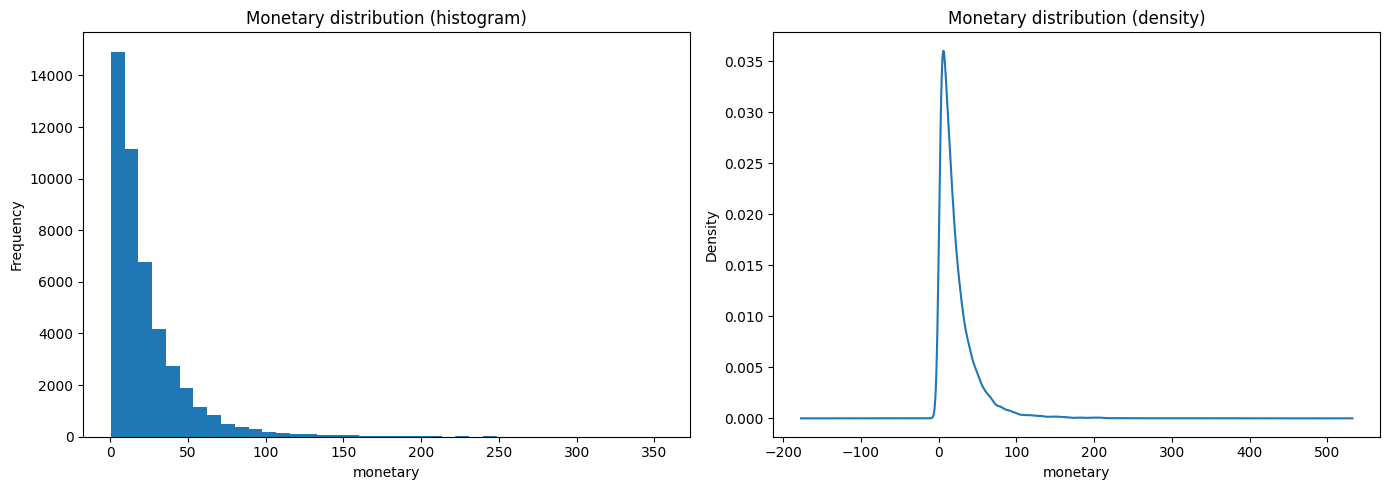

count    45732.000000
mean        22.970028
std         25.823045
min          0.280000
25%          6.940000
50%         15.030000
75%         29.500000
max        354.970000
Name: monetary, dtype: float64

Quantiles:
0.00      0.28
0.10      3.24
0.25      6.94
0.50     15.03
0.75     29.50
0.90     50.93
1.00    354.97
Name: monetary, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Load the table and inspect the monetary distribution

df = pd.read_sql("SELECT * FROM public_mart.fct_rfm_1w", engine)

# Plot histogram and density for the monetary column
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['monetary'].plot(kind='hist', bins=40, ax=axes[0], title='Monetary distribution (histogram)')
axes[0].set_xlabel('monetary')  

if df['monetary'].dtype.kind in 'fi':
    df['monetary'].plot(kind='density', ax=axes[1], title='Monetary distribution (density)')
    axes[1].set_xlabel('monetary')
else:
    axes[1].text(0.5, 0.5, 'monetary is not numeric', ha='center', va='center')

plt.tight_layout()
plt.show()

# Show summary statistics and quantiles to help choose category boundaries
print(df['monetary'].describe())
print('\nQuantiles:')
print(df['monetary'].quantile([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]))

In [34]:
df = pd.read_sql("SELECT customer_id, max(monetary) FROM public_mart.fct_rfm_1w GROUP BY customer_id ORDER BY max(monetary) DESC", engine)
df

,customer_id,max
0,47115,354.97
1,126071,331.39
2,168066,316.68
3,173312,304.62
4,187024,299.44
...,...,...
45727,7532,0.36
45728,63704,0.35
45729,61787,0.32
45730,126976,0.29
